# Model Results

Loads the pretrained RandomForest and XGBoost models from `saved_models/` and reports performance stats (classification report, confusion matrix, precision-recall curve) on the processed test set.

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
)

base_dir = Path.cwd()
TESTING_DATA_PATH = base_dir / "processed_data" / "fraudTest_processed.csv"
RF_MODEL_PATH = base_dir / "saved_models" / "rfboost_model.pkl"
XGB_MODEL_PATH = base_dir / "saved_models" / "xgboost_model.pkl"

In [2]:
# Load test data
df_test = pd.read_csv(TESTING_DATA_PATH)
X_test = df_test.drop("is_fraud", axis=1)
y_test = df_test["is_fraud"]

print(f"Test set shape: {X_test.shape}")
print(f"Fraud rate: {y_test.mean():.4%}")

Test set shape: (555719, 16)
Fraud rate: 0.3860%


In [3]:
def evaluate_model(model, X_test, y_test, model_name, threshold=0.5):
    """Print a classification report and plot the confusion matrix and
    precision-recall curve for a fitted model on held-out test data."""
    probs = model.predict_proba(X_test)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    print(f"===== {model_name} =====")
    print(classification_report(
        y_test, y_pred,
        target_names=["Not Fraud (0)", "Fraud (1)"],
        digits=4
    ))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Fraud (0)", "Fraud (1)"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"{model_name} — Confusion Matrix (rows=Actual, columns=Predicted)")
    plt.show()

    # Precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} — Precision–Recall Curve (Fraud)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_pred, probs

## Random Forest

C:\Users\jaira\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\jaira\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
[Parallel(n_jobs=15)]: Using backend ThreadingBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done  20 tasks      | elapsed:    0.0s
[Parallel(

===== Random Forest =====
               precision    recall  f1-score   support

Not Fraud (0)     0.9973    1.0000    0.9986    553574
    Fraud (1)     0.9842    0.2900    0.4480      2145

     accuracy                         0.9972    555719
    macro avg     0.9907    0.6450    0.7233    555719
 weighted avg     0.9972    0.9972    0.9965    555719



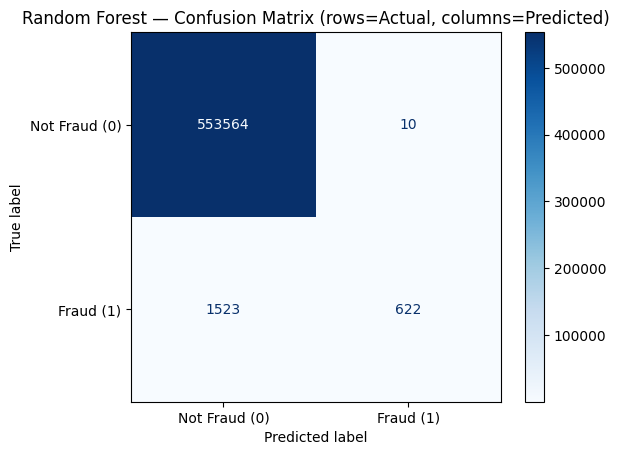

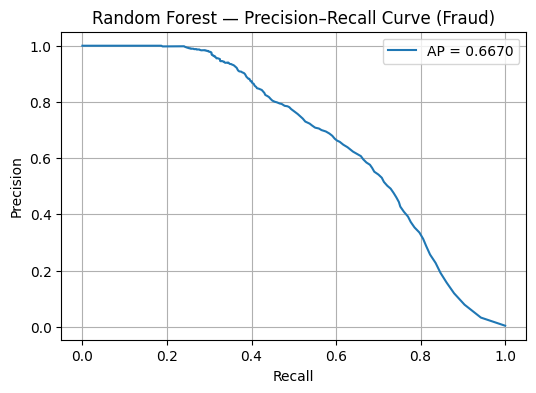

In [4]:
rf_model = joblib.load(RF_MODEL_PATH)
rf_pred, rf_probs = evaluate_model(rf_model, X_test, y_test, "Random Forest")

## XGBoost

c:\Python314\Lib\pickle.py:1835: UserWarning: [16:02:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


===== XGBoost =====
               precision    recall  f1-score   support

Not Fraud (0)     0.9976    0.9999    0.9987    553574
    Fraud (1)     0.9129    0.3716    0.5282      2145

     accuracy                         0.9974    555719
    macro avg     0.9553    0.6857    0.7634    555719
 weighted avg     0.9972    0.9974    0.9969    555719



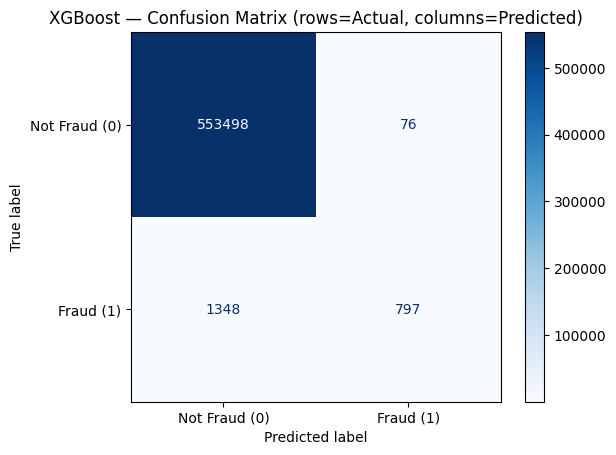

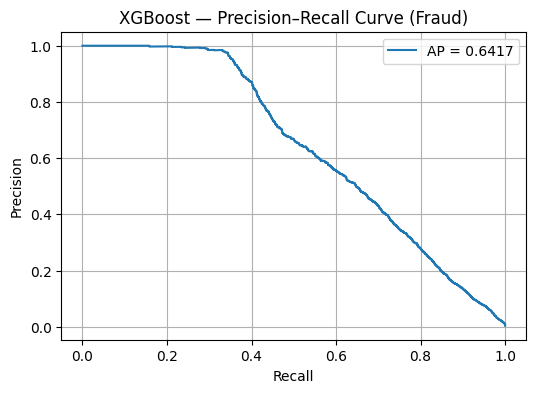

In [5]:
xgb_model = joblib.load(XGB_MODEL_PATH)
xgb_pred, xgb_probs = evaluate_model(xgb_model, X_test, y_test, "XGBoost")

## Side-by-side comparison

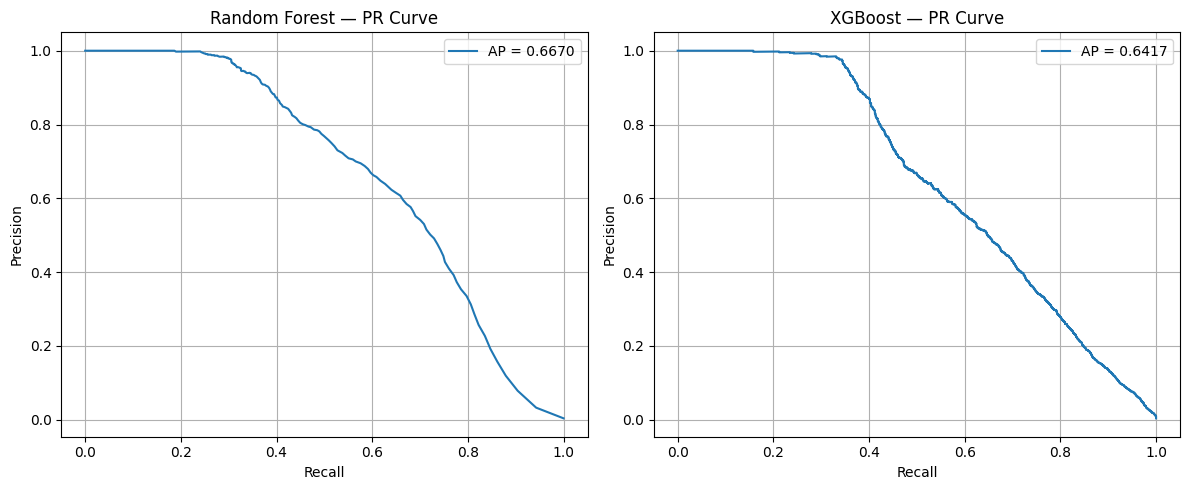

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, probs) in zip(axes, [("Random Forest", rf_probs), ("XGBoost", xgb_probs)]):
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(recall, precision, label=f"AP = {ap:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{name} — PR Curve")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()